# 01 · Experiment diagnostics and power analysis

**Question.** Did the two email campaigns change customer behaviour, and was this test designed well enough to tell us?

**Data.** The Hillstrom MineThatData email test: 64,000 customers who had purchased in the previous twelve months, randomly split into thirds (men's merchandise email, women's merchandise email, no email). Outcomes are measured over the following two weeks: site visit, purchase (conversion) and spend.

**Approach**, in the order a reviewer would want to see it:

1. Check that the data is what it claims to be.
2. Check the randomisation (sample ratio and covariate balance) before looking at any outcome.
3. Estimate effects with uncertainty, correcting for multiple comparisons.
4. Test whether covariate adjustment tightens the estimates.
5. State what this test was powered to detect, and check that figure by simulation.

**Analysis plan.** This is a public dataset whose headline results are widely published, so the plan below is a discipline for the write-up, not a pre-registration.

- Primary outcome: spend per customer, because it is the business-value metric. Secondary outcomes: visit and conversion.
- Primary contrasts: each email arm versus control. Exploratory contrast: men's versus women's email.
- Multiple comparisons: Holm correction across the six primary tests (2 contrasts × 3 outcomes), and a separate Holm correction for the three exploratory tests.
- Two-sided tests at the 5% level; power target of 80%.

In [1]:
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import NormalIndPower, TTestIndPower
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportion_confint,
    test_proportions_2indep,
)

SEED = 20261001
RNG = np.random.default_rng(SEED)
ALPHA = 0.05
POWER = 0.80

DATA_PATH = Path("../data/raw/hillstrom.csv")
TABLE_DIR = Path("../reports/tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print(f"python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | statsmodels {statsmodels.__version__}")

python 3.14.8 | pandas 3.0.6 | numpy 2.5.3 | statsmodels 0.15.0


## 1 · Load and audit the data

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError("Data not found. Run 00_data_acquisition.ipynb first.")

df = pd.read_csv(DATA_PATH)
df["zip_code"] = df["zip_code"].replace({"Surburban": "Suburban"})  # label typo in the source file

ARMS = ["control", "mens_email", "womens_email"]
arm_labels = {"No E-Mail": "control", "Mens E-Mail": "mens_email", "Womens E-Mail": "womens_email"}
df["arm"] = pd.Categorical(df["segment"].map(arm_labels), categories=ARMS, ordered=True)

df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,arm
0,10,2) $100 - $200,142.44,1,0,Suburban,0,Phone,Womens E-Mail,0,0,0.0,womens_email
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,control
2,7,2) $100 - $200,180.65,0,1,Suburban,1,Web,Womens E-Mail,0,0,0.0,womens_email
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,mens_email
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0,womens_email


In [3]:
checks = pd.Series({
    "64,000 rows": len(df) == 64_000,
    "no missing values": df.isna().sum().sum() == 0,
    "every row has a recognised arm": df["arm"].notna().all(),
    "conversion implies visit": bool((df["visit"] >= df["conversion"]).all()),
    "spend > 0 exactly when conversion = 1": bool(((df["spend"] > 0) == (df["conversion"] == 1)).all()),
    "spend within the documented range [0, 500]": bool(df["spend"].between(0, 500).all()),
    "binary columns contain only 0/1": bool(df[["mens", "womens", "newbie", "visit", "conversion"]].isin([0, 1]).all().all()),
}, name="passed")
display(checks.to_frame())
assert checks.all()

,passed
"64,000 rows",True
no missing values,True
every row has a recognised arm,True
conversion implies visit,True
spend > 0 exactly when conversion = 1,True
"spend within the documented range [0, 500]",True
binary columns contain only 0/1,True


### Duplicate rows

The file has no customer identifier, so there is no direct way to confirm that each row is a different person. About one row in ten is an exact duplicate of another. Before deciding what to do about that, the next cell checks whether the duplicates look like repeated records or like different customers who happen to share a profile.

In [4]:
is_dup = df.duplicated(keep="first")
dup_by_arm = df.assign(is_dup=is_dup).groupby("arm", observed=True)["is_dup"].mean().rename("share of rows that duplicate an earlier row")

floor_value = df["history"].min()
floor_share = (df["history"] == floor_value).mean()
no_outcome = (df["visit"] == 0) & (df["conversion"] == 0)

print(f"Exact duplicate rows: {is_dup.sum():,} ({is_dup.mean():.1%})")
print(f"Share of customers at the minimum history value (${floor_value:.2f}): {floor_share:.1%}")
print(f"Rows with no visit and no purchase: {no_outcome.mean():.1%} overall vs {no_outcome[is_dup].mean():.1%} among duplicates")
display(dup_by_arm.to_frame().style.format("{:.1%}"))

def mean_spend_effects(frame):
    m = frame.groupby("arm", observed=True)["spend"].mean()
    return pd.Series({"mens - control": m["mens_email"] - m["control"], "womens - control": m["womens_email"] - m["control"]})

sensitivity = pd.DataFrame({
    "all 64,000 rows": mean_spend_effects(df),
    "duplicates removed": mean_spend_effects(df.drop_duplicates()),
})
display(sensitivity.round(3))

Exact duplicate rows: 6,562 (10.3%)
Share of customers at the minimum history value ($29.99): 12.4%
Rows with no visit and no purchase: 85.3% overall vs 94.0% among duplicates


,share of rows that duplicate an earlier row
arm,
control,10.4%
mens_email,10.0%
womens_email,10.3%


,"all 64,000 rows",duplicates removed
mens - control,0.770,0.851
womens - control,0.424,0.473


**Reading this.** Duplicates appear at similar rates in all three arms, and a large share of customers sit at the minimum history value, so many customers genuinely share the same profile (same recency, channel, region and the minimum spend). Duplicates are also concentrated among customers with no visit and no purchase, so dropping them would remove zero-outcome rows disproportionately and inflate the estimated effects, as the sensitivity table shows. Without an identifier the duplicates cannot be proven benign, but the evidence points that way, and removing them would introduce bias. **All 64,000 rows are kept.**

## 2 · Check the randomisation before looking at outcomes

### Sample ratio mismatch

The design splits customers into equal thirds. A significant departure in arm sizes would suggest the assignment mechanism or the data extraction is broken, and in practice this check is run before anything else. A strict threshold (p < 0.001) is conventional because the check is run routinely and false alarms are costly.

In [5]:
arm_counts = df["arm"].value_counts().reindex(ARMS)
expected = np.full(len(ARMS), len(df) / len(ARMS))
chi2_srm, p_srm = stats.chisquare(arm_counts.to_numpy(), expected)

srm = pd.DataFrame({"observed": arm_counts, "expected": expected.round(1), "share": (arm_counts / len(df)).round(4)})
display(srm)
print(f"Chi-square = {chi2_srm:.3f} on {len(ARMS) - 1} df, p = {p_srm:.3f}  ->  {'investigate' if p_srm < 0.001 else 'no evidence of sample ratio mismatch'}")

,observed,expected,share
arm,,,
control,21306,21333.3,0.3329
mens_email,21307,21333.3,0.3329
womens_email,21387,21333.3,0.3342


Chi-square = 0.203 on 2 df, p = 0.904  ->  no evidence of sample ratio mismatch


### Covariate balance

If assignment was random, pre-treatment characteristics should look the same across arms. The standardised mean difference (SMD) puts every covariate on one scale. With about 21,000 customers per arm, sampling noise alone gives an SMD with standard deviation of roughly 0.01, so differences larger than about 0.03 would be worth a second look. The common rule-of-thumb threshold of 0.1 is far looser than this sample size needs.

Largest |SMD|: 0.0137   (sampling noise SD ≈ 0.0097, so 3 SD ≈ 0.0291)


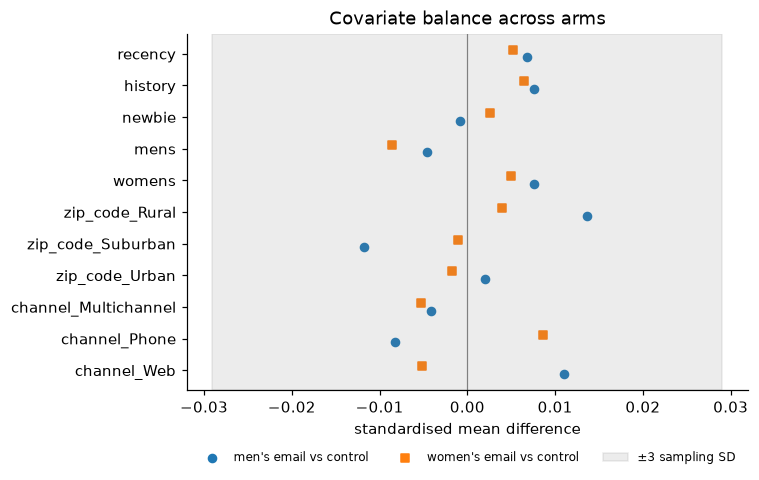

In [6]:
covariate_cols = ["recency", "history", "newbie", "mens", "womens", "zip_code", "channel"]
X_bal = pd.get_dummies(df[covariate_cols], columns=["zip_code", "channel"], dtype=float)

def smd(x_treated, x_control):
    pooled_sd = np.sqrt((x_treated.var(ddof=1) + x_control.var(ddof=1)) / 2)
    return (x_treated.mean() - x_control.mean()) / pooled_sd

smd_table = pd.DataFrame({
    arm: {col: smd(X_bal.loc[df["arm"] == arm, col], X_bal.loc[df["arm"] == "control", col]) for col in X_bal}
    for arm in ["mens_email", "womens_email"]
})

n_per_arm = int(arm_counts.min())
smd_noise_sd = np.sqrt(2 / n_per_arm)  # approximate sampling SD of an SMD between two arms of this size
print(f"Largest |SMD|: {smd_table.abs().to_numpy().max():.4f}   (sampling noise SD ≈ {smd_noise_sd:.4f}, so 3 SD ≈ {3 * smd_noise_sd:.4f})")

fig, ax = plt.subplots(figsize=(7, 4.5))
ypos = np.arange(len(smd_table))
ax.scatter(smd_table["mens_email"], ypos + 0.12, label="men's email vs control", s=28)
ax.scatter(smd_table["womens_email"], ypos - 0.12, label="women's email vs control", s=28, marker="s")
ax.axvline(0, color="grey", lw=0.8)
ax.axvspan(-3 * smd_noise_sd, 3 * smd_noise_sd, color="grey", alpha=0.15, label="±3 sampling SD")
ax.set_yticks(ypos, smd_table.index)
ax.invert_yaxis()
ax.set_xlabel("standardised mean difference")
ax.set_title("Covariate balance across arms")
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3)
plt.tight_layout()
plt.show()

Individual SMDs can each look fine while the covariates jointly predict assignment. The omnibus check below fits a multinomial logistic regression of arm on all covariates and compares it with an intercept-only model using a likelihood-ratio test. A large p-value means the covariates carry no detectable information about which arm a customer was placed in.

In [7]:
X_model = pd.get_dummies(df[covariate_cols], columns=["zip_code", "channel"], drop_first=True, dtype=float)
X_model["history"] = np.log(X_model["history"])  # history is right-skewed
X_model = sm.add_constant(X_model)
y_arm = df["arm"].cat.codes

fit_full = sm.MNLogit(y_arm, X_model).fit(disp=False, maxiter=200)
fit_null = sm.MNLogit(y_arm, X_model[["const"]]).fit(disp=False)

lr_stat = 2 * (fit_full.llf - fit_null.llf)
lr_df = (X_model.shape[1] - 1) * (len(ARMS) - 1)
p_lr = stats.chi2.sf(lr_stat, lr_df)
print(f"Likelihood-ratio test of joint balance: chi-square = {lr_stat:.2f} on {lr_df} df, p = {p_lr:.3f}")

Likelihood-ratio test of joint balance: chi-square = 11.44 on 18 df, p = 0.875


## 3 · Estimate the effects

Binary outcomes use a difference in proportions with a Newcombe confidence interval and a score test, which behave well for rare events such as a 0.6% conversion rate. Spend is zero for most customers and large for a few, so the normal-theory Welch interval is compared with a bootstrap interval as a robustness check.

In [8]:
N_BOOT = 2000

def binary_contrast(a, b, col):
    ya = df.loc[df["arm"] == a, col]
    yb = df.loc[df["arm"] == b, col]
    ca, na, cb, nb_ = int(ya.sum()), len(ya), int(yb.sum()), len(yb)
    lo, hi = confint_proportions_2indep(ca, na, cb, nb_, method="newcomb", compare="diff", alpha=ALPHA)
    p = test_proportions_2indep(ca, na, cb, nb_, method="score", compare="diff").pvalue
    return {"outcome": col, "contrast": f"{a} vs {b}", "mean_a": ca / na, "mean_b": cb / nb_,
            "diff": ca / na - cb / nb_, "ci_low": lo, "ci_high": hi, "p_raw": p,
            "boot_ci_low": np.nan, "boot_ci_high": np.nan}

def mean_contrast(a, b, col):
    ya = df.loc[df["arm"] == a, col].to_numpy()
    yb = df.loc[df["arm"] == b, col].to_numpy()
    diff = ya.mean() - yb.mean()
    se = np.sqrt(ya.var(ddof=1) / len(ya) + yb.var(ddof=1) / len(yb))
    welch = stats.ttest_ind(ya, yb, equal_var=False)
    half = stats.t.ppf(1 - ALPHA / 2, welch.df) * se
    boots = np.array([RNG.choice(ya, len(ya)).mean() - RNG.choice(yb, len(yb)).mean() for _ in range(N_BOOT)])
    b_lo, b_hi = np.percentile(boots, [100 * ALPHA / 2, 100 * (1 - ALPHA / 2)])
    return {"outcome": col, "contrast": f"{a} vs {b}", "mean_a": ya.mean(), "mean_b": yb.mean(),
            "diff": diff, "ci_low": diff - half, "ci_high": diff + half, "p_raw": welch.pvalue,
            "boot_ci_low": b_lo, "boot_ci_high": b_hi}

OUTCOMES = {"visit": binary_contrast, "conversion": binary_contrast, "spend": mean_contrast}

primary = pd.DataFrame([fn(arm, "control", col)
                        for col, fn in OUTCOMES.items() for arm in ["mens_email", "womens_email"]])
exploratory = pd.DataFrame([fn("mens_email", "womens_email", col) for col, fn in OUTCOMES.items()])

for frame in (primary, exploratory):
    frame["rel_lift"] = frame["diff"] / frame["mean_b"]
    reject, p_adj, _, _ = multipletests(frame["p_raw"], alpha=ALPHA, method="holm")
    frame["p_holm"] = p_adj
    frame["significant_holm"] = reject

results = pd.concat([primary.assign(family="primary"), exploratory.assign(family="exploratory")], ignore_index=True)
cols = ["family", "outcome", "contrast", "mean_a", "mean_b", "diff", "ci_low", "ci_high", "rel_lift", "p_raw", "p_holm", "significant_holm"]
display(results[cols].round({"mean_a": 4, "mean_b": 4, "diff": 4, "ci_low": 4, "ci_high": 4, "rel_lift": 3, "p_raw": 4, "p_holm": 4}))

,family,outcome,contrast,mean_a,mean_b,diff,ci_low,ci_high,rel_lift,p_raw,p_holm,significant_holm
0,primary,visit,mens_email vs control,0.1828,0.1062,0.0766,0.0700,0.0832,0.721,0.0000,0.0000,True
1,primary,visit,womens_email vs control,0.1514,0.1062,0.0452,0.0389,0.0516,0.426,0.0000,0.0000,True
2,primary,conversion,mens_email vs control,0.0125,0.0057,0.0068,0.0050,0.0086,1.188,0.0000,0.0000,True
3,primary,conversion,womens_email vs control,0.0088,0.0057,0.0031,0.0015,0.0047,0.543,0.0002,0.0003,True
4,primary,spend,mens_email vs control,1.4226,0.6528,0.7698,0.4851,1.0545,1.179,0.0000,0.0000,True
5,primary,spend,womens_email vs control,1.0772,0.6528,0.4244,0.1690,0.6799,0.650,0.0011,0.0011,True
6,exploratory,visit,mens_email vs womens_email,0.1828,0.1514,0.0314,0.0243,0.0384,0.207,0.0000,0.0000,True
7,exploratory,conversion,mens_email vs womens_email,0.0125,0.0088,0.0037,0.0017,0.0057,0.418,0.0002,0.0004,True
8,exploratory,spend,mens_email vs womens_email,1.4226,1.0772,0.3454,0.0326,0.6583,0.321,0.0305,0.0305,True


In [9]:
spend_rows = results[results["outcome"] == "spend"]
print("Spend: Welch interval vs bootstrap interval for the difference in means")
display(spend_rows[["contrast", "diff", "ci_low", "ci_high", "boot_ci_low", "boot_ci_high"]].round(3))

Spend: Welch interval vs bootstrap interval for the difference in means


,contrast,diff,ci_low,ci_high,boot_ci_low,boot_ci_high
4,mens_email vs control,0.770,0.485,1.055,0.485,1.052
5,womens_email vs control,0.424,0.169,0.680,0.153,0.688
8,mens_email vs womens_email,0.345,0.033,0.658,0.035,0.677


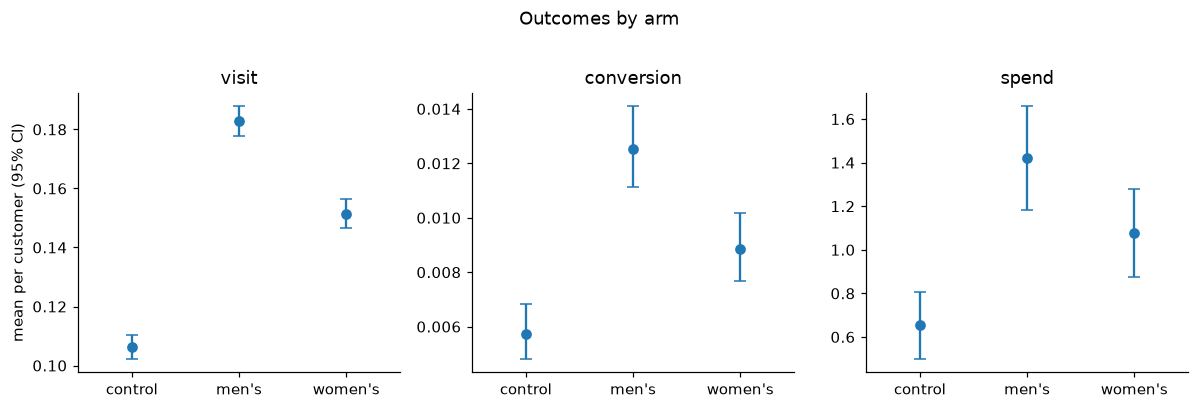

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, col in zip(axes, ["visit", "conversion", "spend"]):
    means, lows, highs = [], [], []
    for arm in ARMS:
        y = df.loc[df["arm"] == arm, col]
        if col == "spend":
            half = 1.96 * y.std(ddof=1) / np.sqrt(len(y))
            lo, hi = y.mean() - half, y.mean() + half
        else:
            lo, hi = proportion_confint(int(y.sum()), len(y), method="wilson")
        means.append(y.mean()); lows.append(lo); highs.append(hi)
    means, lows, highs = map(np.array, (means, lows, highs))
    ax.errorbar(range(3), means, yerr=[means - lows, highs - means], fmt="o", capsize=4)
    ax.set_xticks(range(3), ["control", "men's", "women's"])
    ax.set_title(col)
    ax.set_xlim(-0.5, 2.5)
axes[0].set_ylabel("mean per customer (95% CI)")
plt.suptitle("Outcomes by arm", y=1.02)
plt.tight_layout()
plt.show()

## 4 · Does covariate adjustment help?

Pre-treatment covariates that predict the outcome can shrink the variance of the effect estimate, which is the idea behind CUPED. Three estimators of each email's effect on spend are compared:

1. **Unadjusted**: the plain difference in means (OLS on arm indicators).
2. **Additive adjustment**: OLS with centred covariates added.
3. **Fully interacted adjustment** (Lin, 2013): covariates are centred and interacted with each arm indicator, which stays valid when covariate effects differ by arm and cannot do worse asymptotically than the unadjusted estimate.

All use heteroskedasticity-robust (HC3) standard errors. The achievable gain is bounded by how well the covariates predict spend, so the correlation is reported first.

In [11]:
Xcov = pd.get_dummies(df[covariate_cols], columns=["zip_code", "channel"], drop_first=True, dtype=float)
Xcov["history"] = np.log(Xcov["history"])
Xc = Xcov - Xcov.mean()                                   # centre so arm coefficients are average effects
T = pd.get_dummies(df["arm"], dtype=float)[["mens_email", "womens_email"]]
y_spend = df["spend"]

def effects(kind):
    if kind == "unadjusted":
        X = T
    elif kind == "additive":
        X = pd.concat([T, Xc], axis=1)
    else:  # fully interacted (Lin)
        inter = [Xc.mul(T[t], axis=0).add_suffix(f":{t}") for t in T.columns]
        X = pd.concat([T, Xc] + inter, axis=1)
    res = sm.OLS(y_spend, sm.add_constant(X)).fit(cov_type="HC3")
    return res.params[T.columns], res.bse[T.columns]

control_mask = df["arm"] == "control"
r_hist = np.corrcoef(df.loc[control_mask, "history"], df.loc[control_mask, "spend"])[0, 1]
print(f"Correlation of past-year history with two-week spend (control arm): r = {r_hist:.3f}  ->  r² = {r_hist**2:.4f}")

rows = []
base_se = effects("unadjusted")[1]
for kind in ["unadjusted", "additive", "interacted (Lin)"]:
    est, se = effects("interacted" if kind.startswith("interacted") else kind)
    for arm in T.columns:
        rows.append({"estimator": kind, "contrast": f"{arm} vs control", "estimate": est[arm], "robust_se": se[arm],
                     "se_ratio_vs_unadjusted": se[arm] / base_se[arm],
                     "variance_reduction_pct": 100 * (1 - (se[arm] / base_se[arm]) ** 2)})
adjust = pd.DataFrame(rows)
display(adjust.round({"estimate": 4, "robust_se": 4, "se_ratio_vs_unadjusted": 4, "variance_reduction_pct": 2}))

Correlation of past-year history with two-week spend (control arm): r = 0.015  ->  r² = 0.0002


,estimator,contrast,estimate,robust_se,se_ratio_vs_unadjusted,variance_reduction_pct
0,unadjusted,mens_email vs control,0.7698,0.1452,1.0000,0.00
1,unadjusted,womens_email vs control,0.4244,0.1303,1.0000,0.00
2,additive,mens_email vs control,0.7688,0.1451,0.9992,0.15
3,additive,womens_email vs control,0.4276,0.1304,1.0006,-0.12
4,interacted (Lin),mens_email vs control,0.7680,0.1449,0.9975,0.50
5,interacted (Lin),womens_email vs control,0.4277,0.1305,1.0013,-0.26


## 5 · What was this test able to detect?

The minimum detectable effect (MDE) is the smallest true difference the test would detect with 80% power at the stated significance level. It is reported at the unadjusted 5% level, and again at 0.05/6, which is a conservative stand-in for the multiplicity correction across six primary tests. Proportions use Cohen's h; spend uses a standardised mean difference with the control arm's standard deviation.

In [12]:
ctrl = df[control_mask]
p0 = {"visit": ctrl["visit"].mean(), "conversion": ctrl["conversion"].mean()}
spend_mean, spend_sd = ctrl["spend"].mean(), ctrl["spend"].std(ddof=1)
n_arm = int(arm_counts.min())

def mde_proportion(p_base, n, alpha, power=POWER):
    h = NormalIndPower().solve_power(effect_size=None, nobs1=n, alpha=alpha, power=power, ratio=1.0, alternative="two-sided")
    p_alt = np.sin(np.arcsin(np.sqrt(p_base)) + h / 2) ** 2     # invert Cohen's h
    return p_alt - p_base

def mde_mean(sd, n, alpha, power=POWER):
    d = TTestIndPower().solve_power(effect_size=None, nobs1=n, alpha=alpha, power=power, ratio=1.0, alternative="two-sided")
    return d * sd

ALPHA_BONF = ALPHA / 6
rows = []
for col in ["visit", "conversion"]:
    rows.append({"outcome": col, "control_baseline": p0[col],
                 "mde_abs_alpha_0.05": mde_proportion(p0[col], n_arm, ALPHA),
                 "mde_abs_bonferroni": mde_proportion(p0[col], n_arm, ALPHA_BONF)})
rows.append({"outcome": "spend", "control_baseline": spend_mean,
             "mde_abs_alpha_0.05": mde_mean(spend_sd, n_arm, ALPHA),
             "mde_abs_bonferroni": mde_mean(spend_sd, n_arm, ALPHA_BONF)})
mde = pd.DataFrame(rows).set_index("outcome")
mde["mde_rel_alpha_0.05"] = mde["mde_abs_alpha_0.05"] / mde["control_baseline"]
mde["mde_rel_bonferroni"] = mde["mde_abs_bonferroni"] / mde["control_baseline"]
print(f"Customers per arm used: {n_arm:,}   |   control spend: mean {spend_mean:.3f}, SD {spend_sd:.2f}")
display(mde.round(4))

Customers per arm used: 21,306   |   control spend: mean 0.653, SD 11.59


,control_baseline,mde_abs_alpha_0.05,mde_abs_bonferroni,mde_rel_alpha_0.05,mde_rel_bonferroni
outcome,,,,,
visit,0.1062,0.0085,0.0106,0.0801,0.0999
conversion,0.0057,0.0022,0.0028,0.3894,0.4932
spend,0.6528,0.3145,0.3907,0.4819,0.5985


In [13]:
observed = primary.set_index(["outcome", "contrast"])["diff"].unstack()
comparison = observed.copy()
for col in comparison.index:
    comparison.loc[col] = comparison.loc[col] / mde.loc[col, "mde_abs_bonferroni"]
comparison.columns = [c.replace(" vs control", "") for c in comparison.columns]
print("Observed effect divided by the MDE at the Bonferroni-adjusted level (a ratio above 1 means the test was powered for it)")
display(comparison.round(2))

Observed effect divided by the MDE at the Bonferroni-adjusted level (a ratio above 1 means the test was powered for it)


,mens_email,womens_email
outcome,,
conversion,2.41,1.10
spend,1.97,1.09
visit,7.22,4.26


### Checking the analytical figures by simulation

Analytical power formulas assume approximate normality. For conversion (a 0.6% event) and especially spend (mostly zeros with a heavy right tail) that is worth checking. The simulations below place an effect of exactly the MDE into synthetic experiments and count how often the test rejects.

- **Conversion:** binomial draws at the control rate and at the control rate plus the MDE.
- **Spend:** both arms are resampled from the control arm's observed spend. The treated arm also gets extra purchases, drawn from the observed positive purchase amounts, at a rate chosen so the mean rises by exactly the MDE. This is an "incremental purchases" model of how an email might raise spend.

In [14]:
N_SIM = 2000

def sim_power_conversion(p_base, delta, n, alpha, n_sim=N_SIM):
    x0 = RNG.binomial(n, p_base, n_sim)
    x1 = RNG.binomial(n, p_base + delta, n_sim)
    p_pool = (x0 + x1) / (2 * n)
    se = np.sqrt(2 * p_pool * (1 - p_pool) / n)
    z = (x1 - x0) / n / se
    return float(np.mean(2 * stats.norm.sf(np.abs(z)) < alpha))

pos_spend = ctrl.loc[ctrl["spend"] > 0, "spend"].to_numpy()
ctrl_spend = ctrl["spend"].to_numpy()

def sim_power_spend(delta, n, alpha, n_sim=2000):
    extra_rate = delta / pos_spend.mean()          # share of treated customers with one extra purchase
    hits = 0
    for _ in range(n_sim):
        y0 = RNG.choice(ctrl_spend, n)
        y1 = RNG.choice(ctrl_spend, n) + (RNG.random(n) < extra_rate) * RNG.choice(pos_spend, n)
        hits += stats.ttest_ind(y1, y0, equal_var=False).pvalue < alpha
    return hits / n_sim

arm_sd = df.groupby("arm", observed=True)["spend"].std(ddof=1).rename("SD of spend")
print("The analytical formula assumes both arms have the same spread; observed spread by arm:")
display(arm_sd.round(2).to_frame().T)

spend_mde = mde.loc["spend", "mde_abs_alpha_0.05"]
multiples = [1.0, 1.15, 1.3, 1.45]
spend_curve = pd.Series({m: sim_power_spend(spend_mde * m, n_arm, ALPHA) for m in multiples}, name="simulated power")
spend_curve.index = [f"{m:.2f} × MDE (${spend_mde * m:.2f})" for m in multiples]

conv_mde = mde.loc["conversion", "mde_abs_alpha_0.05"]
sim = pd.DataFrame({
    "effect_simulated": [conv_mde, spend_mde],
    "nominal_power": [POWER, POWER],
    "simulated_power": [sim_power_conversion(p0["conversion"], conv_mde, n_arm, ALPHA), spend_curve.iloc[0]],
}, index=["conversion", "spend"])
display(sim.round(3))
print("Spend: simulated power as the true effect grows beyond the analytical MDE")
display(spend_curve.round(3).to_frame())

The analytical formula assumes both arms have the same spread; observed spread by arm:


arm,control,mens_email,womens_email
SD of spend,11.59,17.75,15.12


,effect_simulated,nominal_power,simulated_power
conversion,0.002,0.8,0.816
spend,0.315,0.8,0.711


Spend: simulated power as the true effect grows beyond the analytical MDE


,simulated power
1.00 × MDE ($0.31),0.711
1.15 × MDE ($0.36),0.818
1.30 × MDE ($0.41),0.894
1.45 × MDE ($0.46),0.937


### Sample size needed to detect smaller effects

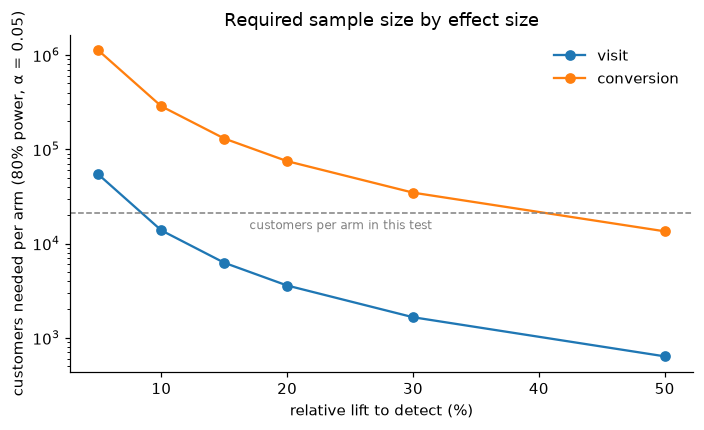

In [15]:
rel_lifts = np.array([0.05, 0.10, 0.15, 0.20, 0.30, 0.50])
curves = {}
for col in ["visit", "conversion"]:
    n_needed = []
    for rl in rel_lifts:
        h = 2 * np.arcsin(np.sqrt(p0[col] * (1 + rl))) - 2 * np.arcsin(np.sqrt(p0[col]))
        n_needed.append(NormalIndPower().solve_power(effect_size=h, nobs1=None, alpha=ALPHA, power=POWER, ratio=1.0))
    curves[col] = np.array(n_needed)

fig, ax = plt.subplots(figsize=(6.5, 4))
for col, n_needed in curves.items():
    ax.plot(rel_lifts * 100, n_needed, marker="o", label=col)
ax.axhline(n_arm, color="grey", ls="--", lw=1)
ax.text(17, n_arm * 0.85, "customers per arm in this test", ha="left", va="top", fontsize=8, color="grey")
ax.set_yscale("log")
ax.set_xlabel("relative lift to detect (%)")
ax.set_ylabel("customers needed per arm (80% power, α = 0.05)")
ax.set_title("Required sample size by effect size")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6 · Summary of results

In [16]:
def fmt_p(p):
    return "< 0.0001" if p < 1e-4 else f"= {p:.4f}"

def fmt_row(r):
    unit = "$" if r["outcome"] == "spend" else ""
    scale = 1 if r["outcome"] == "spend" else 100
    suffix = "" if r["outcome"] == "spend" else " pp"
    return (f"{r['outcome']:<10} {r['contrast']:<28} diff {unit}{r['diff'] * scale:+.3f}{suffix}  "
            f"[{unit}{r['ci_low'] * scale:+.3f}, {unit}{r['ci_high'] * scale:+.3f}]  "
            f"lift {r['rel_lift']:+.0%}  Holm p {fmt_p(r['p_holm'])}")

print(f"Randomisation: sample-ratio p = {p_srm:.3f}; joint covariate balance p = {p_lr:.3f}; largest |SMD| = {smd_table.abs().to_numpy().max():.3f}\n")
print("Primary contrasts (vs control)")
for _, r in primary.iterrows():
    print(" ", fmt_row(r))
print("\nExploratory contrast")
for _, r in exploratory.iterrows():
    print(" ", fmt_row(r))
best_vr = adjust["variance_reduction_pct"].max()
print(f"\nCovariate adjustment: largest variance reduction for spend = {best_vr:.2f}%")

results[cols].to_csv(TABLE_DIR / "01_effect_estimates.csv", index=False)
mde.to_csv(TABLE_DIR / "01_minimum_detectable_effects.csv")
adjust.to_csv(TABLE_DIR / "01_covariate_adjustment.csv", index=False)
print(f"\nTables written to {TABLE_DIR.resolve()}")

Randomisation: sample-ratio p = 0.904; joint covariate balance p = 0.875; largest |SMD| = 0.014

Primary contrasts (vs control)
  visit      mens_email vs control        diff +7.659 pp  [+6.995, +8.323]  lift +72%  Holm p < 0.0001
  visit      womens_email vs control      diff +4.523 pp  [+3.889, +5.157]  lift +43%  Holm p < 0.0001
  conversion mens_email vs control        diff +0.681 pp  [+0.501, +0.864]  lift +119%  Holm p < 0.0001
  conversion womens_email vs control      diff +0.311 pp  [+0.150, +0.475]  lift +54%  Holm p = 0.0003
  spend      mens_email vs control        diff $+0.770  [$+0.485, $+1.055]  lift +118%  Holm p < 0.0001
  spend      womens_email vs control      diff $+0.424  [$+0.169, $+0.680]  lift +65%  Holm p = 0.0011

Exploratory contrast
  visit      mens_email vs womens_email   diff +3.136 pp  [+2.428, +3.843]  lift +21%  Holm p < 0.0001
  conversion mens_email vs womens_email   diff +0.369 pp  [+0.175, +0.566]  lift +42%  Holm p = 0.0004
  spend      mens_email 

## Interpretation and limitations

**What the test shows**

- **The randomisation looks sound.** Arm sizes match equal thirds (p = 0.90), the largest covariate imbalance is 0.014 SMD against sampling noise of about 0.01, and the covariates jointly carry no detectable information about assignment (p = 0.88). The effect estimates can be read as causal for this population.
- **Both emails raised every outcome relative to no email**, and all six primary tests remain significant after Holm correction. The men's email moved visits by about +7.7 percentage points, conversion from 0.57% to 1.25%, and spend by about $0.77 per customer (95% CI roughly $0.49 to $1.06). The women's email moved visits by about +4.5 points, conversion by about +0.3 points, and spend by about $0.42 per customer (95% CI roughly $0.17 to $0.68).
- **Men's versus women's email** is clearly different on visits and conversion. On spend the difference is about $0.35 per customer with a confidence interval of roughly $0.03 to $0.66 and a Holm-adjusted p of about 0.03, which is the weakest result in the notebook. It was an exploratory contrast, so it should be read as suggestive.

**What these results do not support**

- The estimates are for customers who had purchased within the previous twelve months, over a two-week window. They say nothing about lapsed customers, prospects or longer-run behaviour.
- The two emails differ in merchandise content as well as audience. A men's-versus-women's difference therefore mixes content and audience effects, and this data cannot separate them.
- Spend is gross revenue. There is no margin, no email cost, and no unsubscribe or complaint outcome, so the data cannot say whether emailing was profitable or whether it caused list fatigue.
- Only about 0.9% of customers purchased, so the spend intervals rest on a few hundred purchases. The bootstrap and Welch intervals agree closely, with a small difference in the lower bound for the women's email.
- There are no timestamps, so novelty effects, trends within the two weeks and sequential monitoring cannot be examined here.

**Covariate adjustment gave almost nothing.** Past-year spend is almost uncorrelated with two-week spend (r ≈ 0.015), so the best case was a variance reduction of about 0.5%, and one estimate got marginally worse. Adjustment pays off when a pre-period metric tracks the outcome closely, which is not the case in this dataset. A later notebook uses simulation to show how the gain scales with that correlation.

**Power.** At roughly 21,300 customers per arm, the minimum detectable effect at 80% power is about 8% (visit), 39% (conversion) and 48% (spend) relative to control, rising to about 10%, 49% and 60% at the Bonferroni-adjusted level.

- The men's email effects clear those thresholds by a wide margin. The women's email effects on conversion and spend are only about 1.1 times the Bonferroni MDE: detected, but close to the limit of what this test could reliably find.
- Simulation confirmed the formula for conversion (about 82% power at the MDE) but not for spend, where power at the analytical MDE was about 71%. The formula assumes equal spread in both arms, while spend has a standard deviation of about 11.6 in control against 17.8 and 15.1 in the two email arms. A true effect about 15% larger than the formula's MDE restores power to roughly 80%. For heavy-tailed outcomes like this one, simulation is a better planning tool than the closed-form formula.

**Carried forward**

Notebook 02 asks who responds, using the interpretable covariates (recency, past-year spend, channel, region and past merchandise purchases) to estimate how the effect varies across customers. The power findings above set expectations for it: heterogeneity estimates in subgroups of a few thousand customers will be noisy for conversion and spend.